# Pre-class Assignment 4

**Due Sunday night at the start of Week 4**

#### ✅ Owen Sliger

---

## Sound Waves and Signals

Sound waves are everywhere. Our ears are constantly exposed to moving air particles which carry sound waves from vibrations, collisions, richochets, and many other phenomena. These sound waves propagate in the form of differential layers air pressure, which constitute longitudinal wave fronts. In the image below, waves emanate from a speaker in this pattern.

<img src="https://www.researchgate.net/publication/26493787/figure/fig1/AS:310015459119116@1450924853328/A-sound-wave-represented-by-a-picture-of-compressed-and-rarefied-air-particles-a-and-a.png" 
     alt="Alt text here" 
     width="300"/>

The signal shown in the graph indicates how the layers of high pressure and low pressure can be translated into a continuous sine curve. This sinusoidal curve is how we would see the read-out of a microphone, if the microphone were set up to detect this sound wave and transform them into an electrical signal. 

A signal like this can be interpreted as the **amplitude** over **time**. With these two variables alone, you can chart any sound imaginable. Or at least, any sound that could be recorded by a microphone. This is a wonderful property of sound -- it can be added together with other sounds, and the resulting sound waves can be heard all at once. This leads to a question about such combinations:

**Why do we perceive some sound combinations as harmonious, and others as noise?**

---

## Harmony and Noise

We can investigate this question using an example of harmony -- string instruments! String instruments can be tuned, in which case the different notes sound lovely together. They can also become out of tune, which results in displeasing, "noisy" combinations of notes.

Strings produce sound physically through vibration. When a string is plucked, it wavers back and forth, sending differential waves of pressure outward as it does so.

<img src="https://www.physicsclassroom.com/getcontentasset/9a155e50-112a-4c93-bf5a-fd04d6c364e1/a28a7e27-4593-40cf-8266-2ae4101723f5/gsl.gif" 
     alt="Alt text here" 
     width="200"/>

To model this physically, we can think of how a string is set into vibrational motion. For many instruments, this starts with a pluck, in which the string is stretched manually, and then released. From the there, the string snaps back and vibrates, producing sound.

This pluck is a real-world phenomenon. We can use this more concrete example to revise our question:

**Why do strings in tune sound harmonious, whereas strings out of tune sound noisy?**

---

## Modeling a plucked string

At this point, we've formulated a question. That's step 1 of the modeling cycle! To continue with constructing this model, watch the video below. 

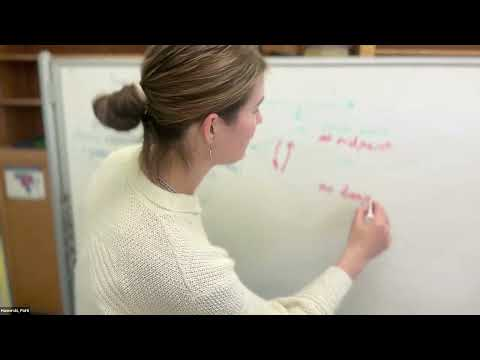

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo("4HiqbL2i4kI", width=800, height=450)

If the YouTube video didn't load, you can access a MediaSpace version here: 
https://media.oregonstate.edu/media/t/1_adb27pt0

**&#9989; Do this:** List at least 3 assumptions you can make to simplify the initial plucked string (before it is released) into a well-defined shape.

- String is anchored at both ends
- String is plucked at a single point
- String is plucked at the midpoint
- String is undamped

**&#9989; Do this:** Create a plot of the initial pluck, using x and y values for the positions of each point along the string.

*Hint: You may want to split this task up into pieces:*
- *Imagine chopping up your string into little pieces, each with their own x-value and y-value.*
- *Create an array of x-values.*
- *Create an array of y-values, ensuring that the y-values peak at location where the string is plucked.*
- *Plot your y-values against your x-values.*

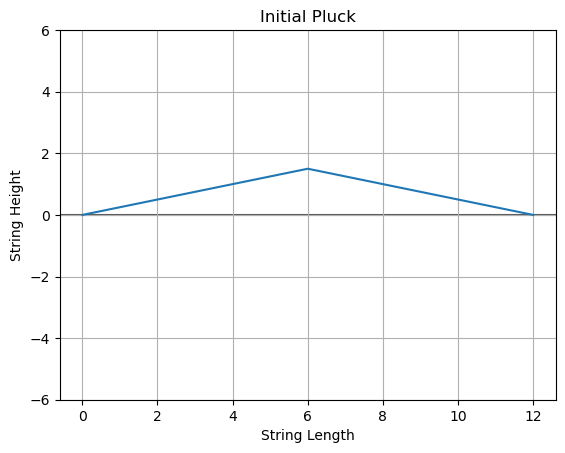

In [62]:
import matplotlib.pyplot as plt
import numpy as np

displacement = 1.5
length = 12
N = (length*2)+1

x = np.linspace(0,length,N)

mid = max(x)/2
condlist = [x <= mid, x > mid]
funclist = [
    lambda x: displacement*(x/mid), 
    lambda x: displacement*(1-(x-mid)/mid)
]
y = np.piecewise(x,condlist,funclist)

fig, ax = plt.subplots()
ax.plot(x,y,zorder=2)
ax.set_ylim(ymin=-6,ymax=6)
ax.axhline(y=0,color='black',alpha=0.65,zorder=1)

ax.set( 
    xlabel='String Length',
    ylabel='String Height',
    title='Initial Pluck'
)
ax.grid()

To model what happens after the pluck is released, let's use some the resources presented in the video below.

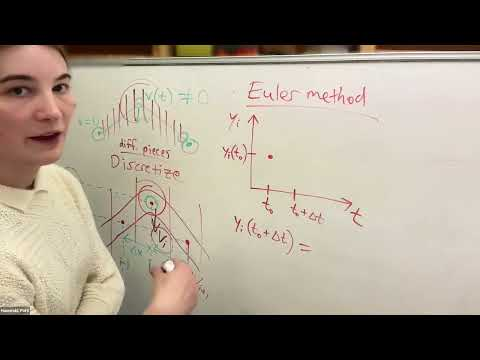

In [8]:
from IPython.display import YouTubeVideo
YouTubeVideo("Q2gfMgQCcRY", width=800, height=450)

If the YouTube video didn't load, you can access a MediaSpace version here: 
https://media.oregonstate.edu/media/t/1_6p114sn3

The Euler method, as presented in the video, is:

$$y(t + \Delta t) = y(t) + v(t) \cdot \Delta t$$

This can be translated into code like this:

```
def string_update(...):
    ...
    t += dt
    y += v * dt
    v += accel * dt
```

Acceleration can be written as the second derivative of y with respect to t: $\partial^2 y / \partial t^2$.

Strings are governed by the wave equation, which conveniently includes this term:

$$\frac{\partial^2 y}{\partial t^2} = c^2 \frac{\partial^2 y}{\partial x^2}$$.

This relationship comes naturally from the fact that the discretized pieces of the string are connected to one another. 
- First, the tiny piece at the top of the pluck is higher than the two pieces next to it. This arrangement indicates a **negative second-derivative in position.** 
- Second, because of the relative heights, the adjacent pieces both pull down on the peak. This force can be translated into a **negative acceleration (second time-derivative).** 
- This relationship between position and time is reflected by the proportionality of the two second-derivatives in the wave equation.

**&#9989; Do this:** What does $c$ represent in the wave equation?

c represents the wave speed

To apply the wave equation to our discretized string model, see the video below.

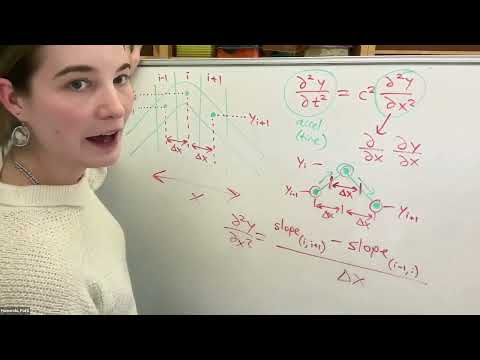

In [58]:
from IPython.display import YouTubeVideo
YouTubeVideo("Ev5zKsVBCqk", width=800, height=450)

If the YouTube video didn't load, you can access a MediaSpace version here:
https://media.oregonstate.edu/media/t/1_86pyfxwe

The finite-difference method presented in the video was:

$$\frac{\partial^2 y_i}{\partial x^2} = \frac{y_{i+1} - 2y_i + y_{i-1}}{\Delta x^2}$$

**&#9989; Do this:** Combine the wave equation and the finite-difference method to produce a formula for acceleration.

$$\frac{\partial^2 y_i}{\partial t^2} = {c^2}\frac{y_{i+1} - 2y_i + y_{i-1}}{\Delta x^2}$$

### That's all! You've reached the end of the pre-class assignment.

Scroll through to make sure you didn't miss any tasks (marked with &#x2705;). Download your work as an HTML file, by selecting: `File` --> `Save and Export Notebook As...` --> `HTML` inside the JupyterHub interface (don't select your browser's File menu). 

Open your downloaded file to ensure the contents look okay, then submit it on Canvas.